## EBM fit

install https://github.com/kurmukovai/ebm-progression by cloning the repo and `pip install -e .`

In [ ]:
from ebm.probability import log_distributions, fit_distributions, predict_stage
from ebm.mcmc import greedy_ascent, mcmc
from ebm.likelihood import EventProbabilities

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

X_train:  (401, 68) float64
cog:  (401, 3)


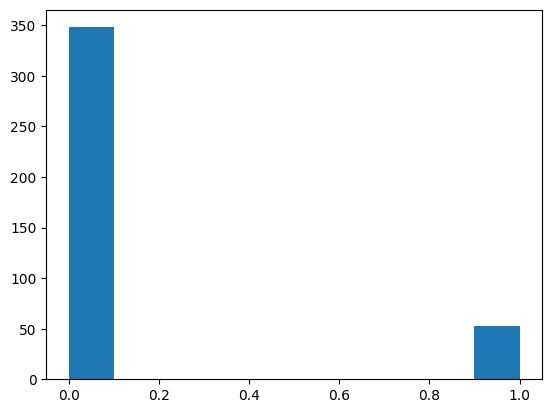

[31 65 61  2 13 18 11 27 41 29  3 21 49  4 22 44 40  5 53 59 12 58  9 39
 62 60 66 23 33 24 50 15  1 46 57 54 37 56 35 52 14 67 10 28 47 20 16  0
 30 48 36 42 38 45 25 43 51 63 55  7 32 17 34  6 26 64  8 19]


In [ ]:


X_val = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_val_68biom.npy", allow_pickle = True)
X_train = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_train_68biom.npy", allow_pickle= True)
K = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/K_68.npy")

biomarker_names = ['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg',
                   'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg',
                   'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg',
                   'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg',
                   'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg',
                   'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg',
                   'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg',
                   'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_thickavg',
                   'L_temporalpole_thickavg', 'L_transversetemporal_thickavg', 'L_insula_thickavg', 'R_bankssts_thickavg', 'R_caudalanteriorcingulate_thickavg',
                   'R_caudalmiddlefrontal_thickavg', 'R_cuneus_thickavg', 'R_entorhinal_thickavg', 'R_fusiform_thickavg', 'R_inferiorparietal_thickavg',
                   'R_inferiortemporal_thickavg', 'R_isthmuscingulate_thickavg', 'R_lateraloccipital_thickavg', 'R_lateralorbitofrontal_thickavg',
                   'R_lingual_thickavg', 'R_medialorbitofrontal_thickavg', 'R_middletemporal_thickavg', 'R_parahippocampal_thickavg', 'R_paracentral_thickavg',
                   'R_parsopercularis_thickavg', 'R_parsorbitalis_thickavg', 'R_parstriangularis_thickavg', 'R_pericalcarine_thickavg', 'R_postcentral_thickavg',
                   'R_posteriorcingulate_thickavg', 'R_precentral_thickavg', 'R_precuneus_thickavg', 'R_rostralanteriorcingulate_thickavg',
                   'R_rostralmiddlefrontal_thickavg', 'R_superiorfrontal_thickavg', 'R_superiorparietal_thickavg', 'R_superiortemporal_thickavg',
                   'R_supramarginal_thickavg', 'R_frontalpole_thickavg', 'R_temporalpole_thickavg', 'R_transversetemporal_thickavg', 'R_insula_thickavg']


def unpack_patient_list(patient_list):
    X_obs = []
    dt = []
    ids = []
    cog = []
    nhy = []
    for patient in patient_list:
        n_visits = patient["dt"].shape[0]
        pid = patient["id"]
        X_obs.append(patient["X_obs"])
        dt.append(patient["dt"])
        ids.append(np.full(n_visits, pid))
        cog.append(patient["cog"])
        nhy.append(patient["nhy"])
    return (
        np.vstack(X_obs),
        np.concatenate(dt),
        np.concatenate(ids),
        np.vstack(cog),
        np.concatenate(nhy),
    )

    
X_train_obs, X_train_dt, X_train_ids, X_train_cog, X_train_nhy = unpack_patient_list(X_train)
X_val_obs, X_val_dt, X_val_ids, X_val_cog, X_val_nhy = unpack_patient_list(X_val)


#y = np.ones(X_train_obs.shape[0])

print("X_train: ", X_train_obs.shape, X_train_obs.dtype)
print("cog: ", X_train_cog.shape)
df_train = pd.DataFrame({
    "dt": X_train_dt,
    "MCATOT": X_train_cog[:, 0],
    "TD_score": X_train_cog[:, 2],
    "PIDG_score": X_train_cog[:, 1],
})

df_train["stage_label"] = (df_train["dt"] > df_train["dt"].mean()).astype(int)
X_cog = df_train[["MCATOT", "TD_score", "PIDG_score"]].values
y_binary = df_train["stage_label"].values
logit = LogisticRegression()
logit.fit(X_cog, y_binary)
y_train = logit.predict(X_cog)
plt.figure()
plt.hist(y_train)
plt.show()

log_p_e, log_p_not_e = log_distributions(X=X_train_obs, y=y_train, point_proba=False)
rng = np.random.RandomState(75)
starting_order = np.arange(0,68, dtype=int)
rng.shuffle(starting_order)
print(starting_order)

In [10]:
order, loglike, update_iters = greedy_ascent(log_p_e, log_p_not_e, 
                                             n_iter=10_000, order = starting_order,
                                             random_state=2020, prior=K)

100%|██████████| 10000/10000 [00:08<00:00, 1168.06it/s]


In [11]:
# almost correct, good job
order

array([41, 39, 56, 32, 47, 13, 34, 63, 36,  7, 26, 29, 22, 60,  2, 62, 57,
       48,  6, 23, 40, 61,  5,  9, 28, 49, 19, 11, 18, 66, 67, 65,  0, 20,
       25, 43, 50, 10, 17, 53, 64, 44, 59, 51, 54, 15, 27, 37, 45,  1, 24,
       31,  3, 58, 33, 14, 16, 12, 52, 46, 21, 42, 30,  8, 55,  4, 38, 35])

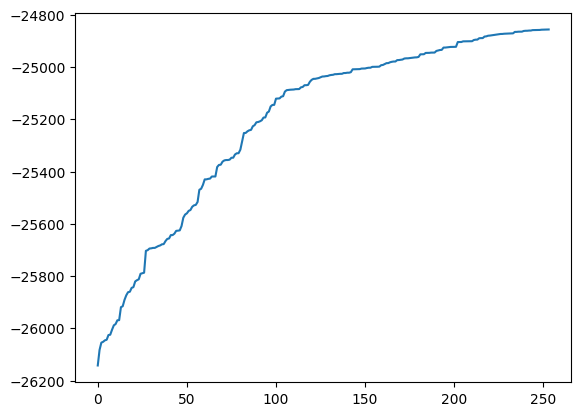

In [12]:
plt.plot(loglike)

In [13]:
orders, loglike, update_iters, probas = mcmc(log_p_e, log_p_not_e,
                                                 order=order, n_iter=500_000,
                                                 random_state=2020)

100%|██████████| 500000/500000 [07:00<00:00, 1187.73it/s]


In [ ]:
#orders[:10]
print(len(orders))
if orders == []:
    best_order = order
else:
    best_order = orders[np.argmax(loglike)]
    
print(best_order)

predict_stage(best_order)

plt.figure(figsize=(15,15))

31105
[41 39 62 32 47 56 34 13 63  2 36 26  7 29 22 60 40 23 57  6 48 61 27  9
  5 49 28 15 18 67 20  1  0 66 19 37 25 10 59 64 54 51 44 31 53 45 43 52
 11  4 35 38 30 16  8 50 33 58 46 42 14 65 21 55  3 12 24 17]
